In [ ]:
import sys
import gc
import ast

import pandas as pd
import numpy as np
import datetime as dt

from statsmodels.tsa.api import DynamicFactorMQ

from pib_nowcast.config import SERIES_SPEC, LAST_DATA, DATA_DIR
from pib_nowcast.utils.get_data import get_data
from pib_nowcast.utils.transformations import seas_adj_stl_parallel, make_stationary, deflate
from pib_nowcast.utils.news import get_news_impacts, get_new_forecasts

In [ ]:
### Especifica caminho e primeira data
specs_df = pd.read_csv(SERIES_SPEC, sep=';')
start_date = '1996-01-01'

### Especificação de datas
today = dt.date.today()

In [ ]:
## Dataset completo, última run
old_full_data = pd.read_excel(LAST_DATA, sheet_name='full_dataset', index_col='Date')

## Coleta dados mais recentes

### Junta tudo num df só
new_full_data = get_data(specs_df, start_date)

In [ ]:
if old_full_data.equals(new_full_data):
    print("Sem dados novos ou revisões, encerrando processso.")
    sys.exit(0)

else:
    print('Houve atualização/revisão nos dados, prosseguindo com o processo.')

Houve atualização/revisão nos dados, prosseguindo com o processo.


In [ ]:
## -> Deflacionar valores nominais
old_full_data_defl = deflate(old_full_data, specs_df)
new_full_data_defl = deflate(new_full_data, specs_df)

## -> Ajuste sazonal
old_full_data_sa = seas_adj_stl_parallel(old_full_data_defl, specs_df)
new_full_data_sa = seas_adj_stl_parallel(new_full_data_defl, specs_df)

## -> Estacionarização
old_full_data_stat = make_stationary(old_full_data_sa, specs_df)
new_full_data_stat = make_stationary(new_full_data_sa, specs_df)

In [ ]:
## Caso onde houve atualização do PIB
if old_full_data['pib'].last_valid_index() < new_full_data['pib'].last_valid_index():
    pib_series = new_full_data[['pib']].dropna()
else:
    pib_series = old_full_data[['pib']].dropna()

last_pib_date_timestamp = pib_series.last_valid_index()

# Definir próximo trimestre do PIB
next_pib_quarter_timestamp = last_pib_date_timestamp + pd.DateOffset(months=3)

In [ ]:
del old_full_data, new_full_data, old_full_data_sa, new_full_data_sa
gc.collect()

140

In [ ]:
# Extrai os fatores especificados e corrige o tipo dos dados
factors = specs_df.set_index('variable')['factors'].to_dict()
factors = {
    k: ast.literal_eval(v) if isinstance(v, str) else v
    for k, v in factors.items()
}

old_model = DynamicFactorMQ(
    endog = old_full_data_stat,
    k_endog_monthly = specs_df.query("frequency == 'Monthly' ").shape[0],
    factors = factors,
    # factor_multiplicities={ 'Global': 2 },
    # factor_orders = {
    #     'Global': 4,
    #     ('Output', 'Employment', 'Prices', 'Sentiment', 'Credit'): 1
    # }
).fit()

print(old_model.summary())

                                       Dynamic Factor Results                                      
Dep. Variable:     "pim_industria_extrativa", and 157 more   No. Observations:                  366
Model:                                Dynamic Factor Model   Log Likelihood              -51306.641
                                   + 6 factors in 6 blocks   AIC                         103901.281
                                   + Mixed frequency (M/Q)   BIC                         106414.577
                                     + AR(1) idiosyncratic   HQIC                        104899.995
Date:                                     Thu, 16 Jul 2026   EM Iterations                       70
Time:                                             09:28:16                                         
Sample:                                         01-01-1996                                         
                                              - 06-01-2026                                         


In [ ]:
new_model = old_model.apply(
    endog = new_full_data_stat,
    k_endog_monthly = specs_df.query("frequency == 'Monthly' ").shape[0],

)

In [ ]:
news = new_model.news(
    comparison=old_model, 
    impacted_variable='pib', 
    impact_date=next_pib_quarter_timestamp.strftime('%Y-%m-%d'),
    # tolerance=1e-5,
    comparison_type='previous',
    revisions_details_start=-12  # Limita as matrizes de revisões apenas para os últimos 12 meses
)
print(news.summary())

                                       News                                       
Model:                DynamicFactorMQ   Original sample:       1996-01-01 00:00:00
Date:                Thu, 16 Jul 2026                        - 2026-06-01 00:00:00
Time:                        09:28:42   Update through:        2026-07-01 00:00:00
                                        # of revisions:                        708
                                        # of new datapoints:                     2
                              Impacts for [impacted variable = pib]                               
        impact date estimate (prev) impact of revisions impact of news total impact estimate (new)
--------------------------------------------------------------------------------------------------
2026-06-01 00:00:00            2.14                0.00          -0.00        -0.00           2.14
                      News from updated observations:                      
        update date updated va

In [ ]:
## -> Salvar impactos no histórico
get_news_impacts(news, save_to=DATA_DIR / 'news_impacts.xlsx')


## -> Salvar novos forecasts no histórico
forecasts_df = get_new_forecasts(
    news=news, 
    new_model_res=new_model, 
    last_pib_date_timestamp=last_pib_date_timestamp, 
    next_pib_quarter_timestamp=next_pib_quarter_timestamp, 
    historical_pib_index=pib_series,
    save_to=DATA_DIR / 'forecasts.xlsx'
)

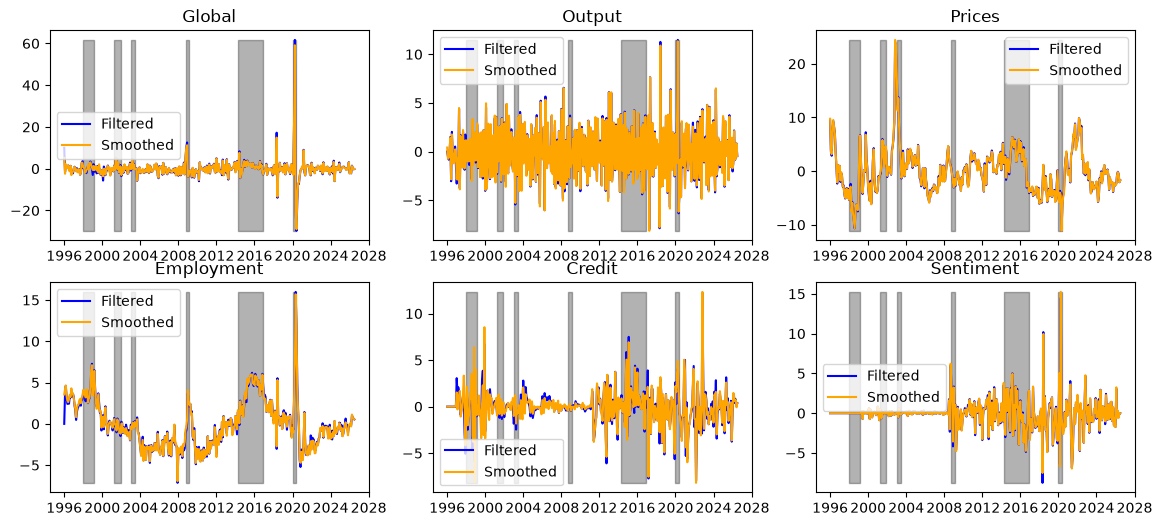

In [ ]:
filtered_factors = new_model.factors['filtered']
smoothed_factors = new_model.factors['smoothed']

recessions1 =    pd.date_range(start='1998-01-01', end='1999-03-01', freq='MS').to_list() 
recessions2 =    pd.date_range(start='2001-04-01', end='2001-12-01', freq='MS').to_list()
recessions3 =    pd.date_range(start='2003-01-01', end='2003-06-01', freq='MS').to_list()
recessions4 =    pd.date_range(start='2008-10-01', end='2009-03-01', freq='MS').to_list()
recessions5 =    pd.date_range(start='2014-04-01', end='2016-12-01', freq='MS').to_list()
recessions6 =    pd.date_range(start='2020-01-01', end='2020-06-01', freq='MS').to_list()

recessions = [recessions1, recessions2, recessions3, recessions4, recessions5, recessions6]

def _add_recessions(recessions, ax, ymin, ymax):
    for recession in recessions:
        ax.fill_between(x=recession, y1=ymin, y2=ymax, color='black', alpha=0.3)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(14, 6))

ax = ax.ravel()

for i, factor in enumerate(filtered_factors.columns):

    ax[i].set_title(factor)
    ax[i].plot(filtered_factors.index, filtered_factors[factor], label='Filtered', color='blue')
    ax[i].plot(smoothed_factors.index, smoothed_factors[factor], label='Smoothed', color='orange')
    ax[i].legend()
    _add_recessions(
                    recessions, 
                    ax[i], 
                    ymin=min(filtered_factors[factor].min(), smoothed_factors[factor].min()), 
                    ymax=max(filtered_factors[factor].max(), smoothed_factors[factor].max())
                )

In [ ]:
import statsmodels.api as sm

In [ ]:

new_model.predict()

,pim_industria_extrativa,pim_industria_transformacao,pim_bens_capital,pim_bens_intermediarios,pim_bens_consumo,pim_bens_duraveis,pim_bens_semi_e_nao_duraveis,pim_insumo_constr_civil,cons_energ_comercial,cons_energ_residencial,...,geracao_energ_termica,geracao_energ_termonuclear,geracao_energ_eolica,geracao_energ_solar,papelao_expedicao,prod_fertilizante,icc_fgv,icc_fgv_sit_atual,icc_fgv_expectativas,pib
1996-01-01,0.158551,0.043062,0.123326,0.046184,0.044351,0.120884,0.030217,-0.172010,0.336045,0.295038,...,0.704787,15.335159,12.019648,111.374921,0.246625,-0.028908,-0.123974,-0.131642,-0.114457,2.289136
1996-02-01,0.058455,-0.526738,-0.906288,-0.303697,-0.646804,-2.533458,-0.368095,-0.888224,0.033185,0.277253,...,0.419195,14.684954,11.451414,111.762482,-0.224395,-0.056582,-0.599805,-0.413429,-0.780532,0.619946
1996-03-01,0.146662,0.107777,0.240897,0.082119,0.124394,0.321029,0.082376,-0.035770,-0.801356,-0.869205,...,8.466743,12.814009,11.546380,98.026455,0.192470,0.035852,-0.049415,-0.087489,-0.010088,1.358123
1996-04-01,0.100793,-0.075865,-0.090571,-0.032871,-0.097457,-0.593737,-0.041947,-0.234479,0.049811,-0.122339,...,-4.884824,10.534547,11.048543,90.366203,0.471075,0.062989,-0.190768,-0.171197,-0.207955,1.525150
1996-05-01,0.137820,-0.039984,-0.026568,-0.005814,-0.055973,-0.292735,-0.026007,-0.261895,0.176034,0.270713,...,-3.061476,22.514717,11.794779,107.917254,-0.409224,-0.016666,-0.187905,-0.169502,-0.203948,1.329230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-01,0.044524,-0.044263,-0.292047,-0.036152,0.148735,1.108187,-0.001001,0.147710,0.647830,1.217575,...,-6.106547,13.622120,13.164683,86.757411,1.017197,-0.329547,0.215699,-0.046314,0.366032,1.669658
2026-04-01,0.273070,0.476388,0.875550,0.194555,0.513336,1.996033,0.265307,-0.176802,0.955454,1.750493,...,-1.393776,20.063025,15.004607,166.244530,-0.573266,-0.208358,-0.073961,0.057103,-0.121108,2.397684
2026-05-01,-0.211455,-0.381702,-0.351818,-0.289134,-0.057054,-0.258791,-0.084090,0.114178,-0.473829,-1.343906,...,12.365395,18.413353,10.858010,89.677771,0.248319,-0.299901,-0.169278,-0.254820,-0.330093,2.711629
2026-06-01,0.410617,-0.072635,0.078278,0.066472,0.182255,-1.638662,0.474687,-0.841383,0.232751,0.286704,...,1.368015,15.582350,11.889022,94.870979,1.134633,0.123046,-0.178496,-0.113832,-0.004938,2.089555


In [ ]:

new_model.predict()[['pib']]

,pib
1996-01-01,2.289136
1996-02-01,0.619946
1996-03-01,1.358123
1996-04-01,1.525150
1996-05-01,1.329230
...,...
2026-03-01,1.669658
2026-04-01,2.397684
2026-05-01,2.711629
2026-06-01,2.089555


<Axes: >

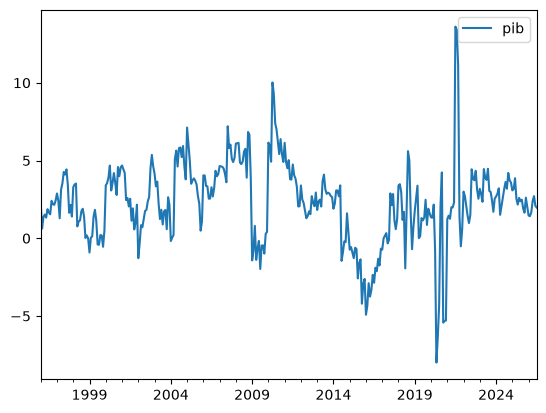

In [ ]:
new_model.predict()[['pib']].plot()

In [ ]:
old_full_data = pd.read_excel(LAST_DATA, sheet_name='full_dataset', index_col='Date')

<Axes: xlabel='Date'>

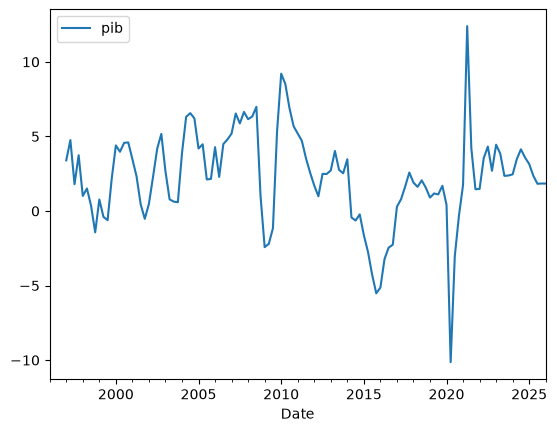

In [ ]:
old_full_data[['pib']].dropna().pct_change(4).multiply(100).plot()

In [ ]:
start = '2000-03-01'
end = '2026-03-01'

mdl = sm.OLS(
    endog = new_model.predict().loc[start:end, ['pib']],
    exog = smoothed_factors.loc[start:end].pipe(sm.add_constant),
).fit(cov_type='HAC', cov_kwds={'maxlags':12})

print(mdl.summary())

                            OLS Regression Results                            
Dep. Variable:                    pib   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     15.73
Date:                Thu, 16 Jul 2026   Prob (F-statistic):           9.38e-16
Time:                        09:52:50   Log-Likelihood:                -672.74
No. Observations:                 313   AIC:                             1359.
Df Residuals:                     306   BIC:                             1386.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0383      0.188     10.840      0.0

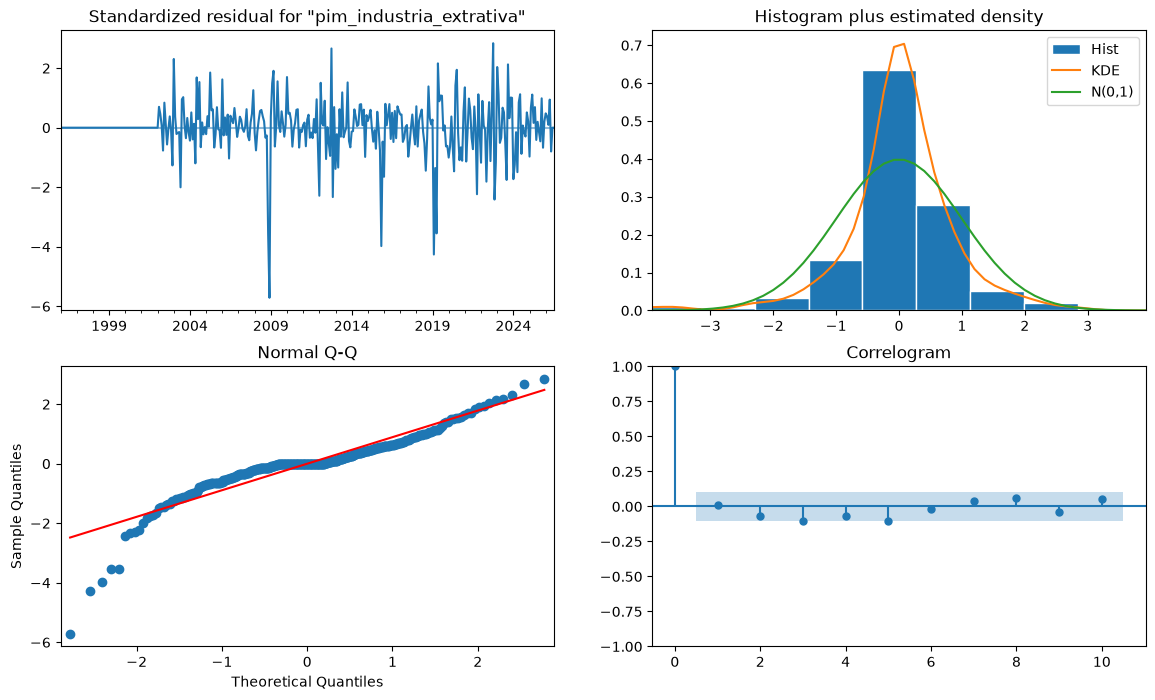

In [ ]:
new_model.plot_diagnostics(figsize=(14,8));

In [ ]:
# Nova especificação abaixo

In [ ]:
import sys
import gc
import ast

import pandas as pd
import numpy as np
import datetime as dt

from statsmodels.tsa.api import DynamicFactorMQ

from pib_nowcast.config import SERIES_SPEC, LAST_DATA, DATA_DIR
from pib_nowcast.utils.get_data import get_data
from pib_nowcast.utils.transformations import seas_adj_stl_parallel, make_stationary, deflate
from pib_nowcast.utils.news import get_news_impacts, get_new_forecasts

In [ ]:
### Especifica caminho e primeira data
specs_df = pd.read_csv(SERIES_SPEC, sep=';')
start_date = '1996-01-01'

### Especificação de datas
today = dt.date.today()

In [ ]:
## Dataset completo, última run
old_full_data = pd.read_excel(LAST_DATA, sheet_name='full_dataset', index_col='Date')

## Coleta dados mais recentes

### Junta tudo num df só
new_full_data = get_data(specs_df, start_date)

In [ ]:
if old_full_data.equals(new_full_data):
    print("Sem dados novos ou revisões, encerrando processso.")
    sys.exit(0)

else:
    print('Houve atualização/revisão nos dados, prosseguindo com o processo.')

Houve atualização/revisão nos dados, prosseguindo com o processo.


In [ ]:
## -> Deflacionar valores nominais
old_full_data_defl = deflate(old_full_data, specs_df)
new_full_data_defl = deflate(new_full_data, specs_df)

## -> Ajuste sazonal
old_full_data_sa = seas_adj_stl_parallel(old_full_data_defl, specs_df)
new_full_data_sa = seas_adj_stl_parallel(new_full_data_defl, specs_df)

## -> Estacionarização
old_full_data_stat = make_stationary(old_full_data_sa, specs_df)
new_full_data_stat = make_stationary(new_full_data_sa, specs_df)

In [ ]:
## Caso onde houve atualização do PIB
if old_full_data['pib'].last_valid_index() < new_full_data['pib'].last_valid_index():
    pib_series = new_full_data[['pib']].dropna()
else:
    pib_series = old_full_data[['pib']].dropna()

last_pib_date_timestamp = pib_series.last_valid_index()

# Definir próximo trimestre do PIB
next_pib_quarter_timestamp = last_pib_date_timestamp + pd.DateOffset(months=3)

In [ ]:
del old_full_data, new_full_data, old_full_data_sa, new_full_data_sa
gc.collect()

978

In [ ]:
# Extrai os fatores especificados e corrige o tipo dos dados
factors = specs_df.set_index('variable')['factors'].to_dict()
factors = {
    k: ast.literal_eval(v) if isinstance(v, str) else v
    for k, v in factors.items()
}

old_model = DynamicFactorMQ(
    endog = old_full_data_stat,
    k_endog_monthly = specs_df.query("frequency == 'Monthly' ").shape[0],
    factors = factors,
    factor_multiplicities={ 'Global': 2 },
    # factor_orders = {
    #     'Global': 4,
    #     ('Output', 'Employment', 'Prices', 'Sentiment', 'Credit'): 1
    # }
).fit()

print(old_model.summary())

                                       Dynamic Factor Results                                      
Dep. Variable:     "pim_industria_extrativa", and 157 more   No. Observations:                  366
Model:                                Dynamic Factor Model   Log Likelihood              -50111.838
                                   + 7 factors in 6 blocks   AIC                         101837.676
                                   + Mixed frequency (M/Q)   BIC                         104987.101
                                     + AR(1) idiosyncratic   HQIC                        103089.169
Date:                                     Thu, 16 Jul 2026   EM Iterations                       75
Time:                                             10:22:14                                         
Sample:                                         01-01-1996                                         
                                              - 06-01-2026                                         


In [ ]:
new_model = old_model.apply(
    endog = new_full_data_stat,
    k_endog_monthly = specs_df.query("frequency == 'Monthly' ").shape[0],

)

In [ ]:
news = new_model.news(
    comparison=old_model, 
    impacted_variable='pib', 
    impact_date=next_pib_quarter_timestamp.strftime('%Y-%m-%d'),
    # tolerance=1e-5,
    comparison_type='previous',
    revisions_details_start=-12  # Limita as matrizes de revisões apenas para os últimos 12 meses
)
print(news.summary())

                                       News                                       
Model:                DynamicFactorMQ   Original sample:       1996-01-01 00:00:00
Date:                Thu, 16 Jul 2026                        - 2026-06-01 00:00:00
Time:                        10:22:38   Update through:        2026-07-01 00:00:00
                                        # of revisions:                        708
                                        # of new datapoints:                     2
                              Impacts for [impacted variable = pib]                               
        impact date estimate (prev) impact of revisions impact of news total impact estimate (new)
--------------------------------------------------------------------------------------------------
2026-06-01 00:00:00            2.36                0.00          -0.00        -0.00           2.36
                      News from updated observations:                      
        update date updated va

IndexError: index 6 is out of bounds for axis 0 with size 6

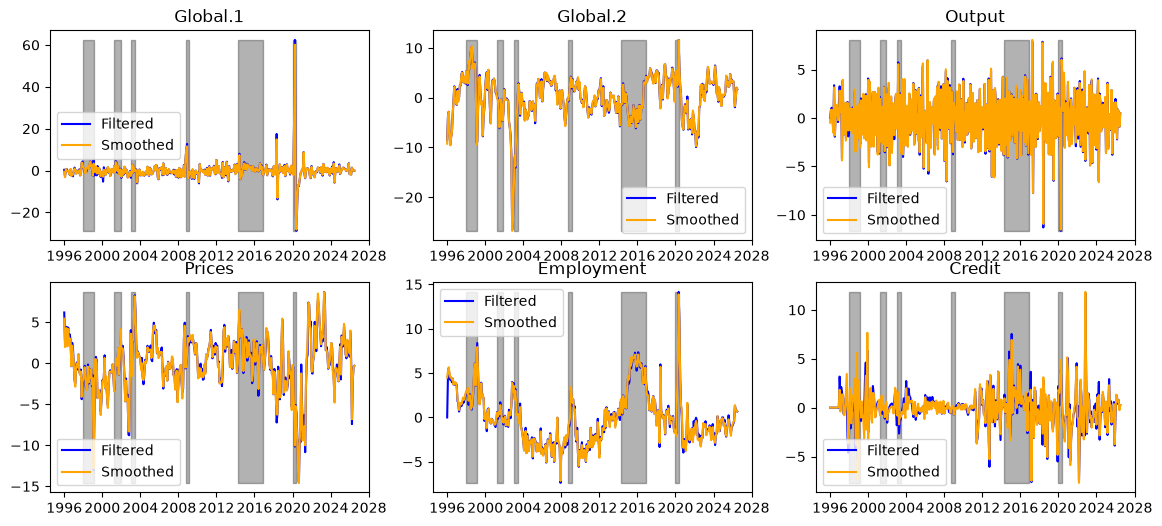

In [ ]:
filtered_factors = new_model.factors['filtered']
smoothed_factors = new_model.factors['smoothed']

recessions1 =    pd.date_range(start='1998-01-01', end='1999-03-01', freq='MS').to_list() 
recessions2 =    pd.date_range(start='2001-04-01', end='2001-12-01', freq='MS').to_list()
recessions3 =    pd.date_range(start='2003-01-01', end='2003-06-01', freq='MS').to_list()
recessions4 =    pd.date_range(start='2008-10-01', end='2009-03-01', freq='MS').to_list()
recessions5 =    pd.date_range(start='2014-04-01', end='2016-12-01', freq='MS').to_list()
recessions6 =    pd.date_range(start='2020-01-01', end='2020-06-01', freq='MS').to_list()

recessions = [recessions1, recessions2, recessions3, recessions4, recessions5, recessions6]

def _add_recessions(recessions, ax, ymin, ymax):
    for recession in recessions:
        ax.fill_between(x=recession, y1=ymin, y2=ymax, color='black', alpha=0.3)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 3, figsize=(14, 6))

ax = ax.ravel()

for i, factor in enumerate(filtered_factors.columns):

    ax[i].set_title(factor)
    ax[i].plot(filtered_factors.index, filtered_factors[factor], label='Filtered', color='blue')
    ax[i].plot(smoothed_factors.index, smoothed_factors[factor], label='Smoothed', color='orange')
    ax[i].legend()
    _add_recessions(
                    recessions, 
                    ax[i], 
                    ymin=min(filtered_factors[factor].min(), smoothed_factors[factor].min()), 
                    ymax=max(filtered_factors[factor].max(), smoothed_factors[factor].max())
                )